# Simulation Testing

Author: Joshua Holmes (jbh92@case.edu)

The following notebook tests various aspects of the myo5space repository that do not lend themselves well to automated testing. In particular, the average run distance, run time, run velocity, and dwell time of a wide range of hypothetical motors are calculated via kinetic Monte Carlo (KMC), event Monte Carlo (EMC), or analytical (ana) approaches, then compared to each other to identify any numerical limitations or inconsistencies.

# Imports and Global Settings

In [ ]:
from myo5space import simtesting
from myo5space.simtesting import SimTestingRes
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


In [2]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['lines.linewidth'] = 2

In [3]:
# Path to directory for saving data.
path = Path.cwd()

# Simulations

Running the simulations from scratch takes a very long time (12 hours on an Intel i5-1345U). Results will load from a file if available.

The code run in the following section creates several motors with different kd1, kd2, kh, kfpp, and kfpm rates ranging over several orders of magnitude. The constraint that kfpp > kfpm is imposed to prevent motors with large negative run distances. Note that varying kfpp and kfpm effectively mimics the effects of varying the various structural parameters. kps is set to infinity for all motors since one of the underlying assumptions is that the power stroke will occur faster than any other rate. Furthermore, finite kps values only lengthen run and dwell times, with no impact on run distance or event probabilities.

For each motor, simulations are run using either the KMC or EMC backend along with the analytical predictions. By default, 1000 random motors are tested and 100,000 trials are ued for KMC and EMC simulations. The results, along with the motors and kfpp and kfpm values, are saved to a file for later use.

In [4]:
pickle_path = path.joinpath("simtesting_res.p")
simres = SimTestingRes.load(pickle_path) if pickle_path.exists() else SimTestingRes()
if not simres.check_ok():
    print("Running simulations")
    simres.run_all()
    simres.save(pickle_path)
else:
    print("Loaded results were OK.")

Loaded results were OK.


# Results

The results from the simulations and analytical calculations are analyzed and compared against each other. Average run distances, run times, run velocities, and dwell times for each motor are compared between methods by calculating the relative error between them (ana - KMC, ana - EMC, KMC - EMC) and plotted as a histogram. Simulations are rerun for the motor with the highest relative error to show how it can be improved. Additional testing to explain any poor agreement between methods or other sources of error is also offered.

In [5]:
def plot_residuals(ak, ae, ke, figtitle):
    fig, axs = plt.subplots(3, 1, figsize=(4,4), sharex=True)
    axs = axs.flatten()
    titles = ['Analytic - KMC', 'Aanalytic - EMC', 'KMC - EMC']
    colors = {title : c for title, c in zip(titles, ['b', 'r', 'g'])}
    for ax, residual, title in zip(axs, [ak, ae, ke], titles):
        _toplot = residual.astype(float)
        _toplot = np.log10(_toplot[_toplot != 0])
        ax.hist(_toplot, bins=100, label=title, color=colors.get(title))
        ax.set_ylabel('counts')
        ax.legend(fontsize='x-small', loc=2)
    
    axs[0].set_title(figtitle)
    axs[2].set_xlabel('Log10 Rel. Difference')
    
    return fig


def residuals(ana, kmc, emc, figtitle):
    ak, ae, ke = simtesting.calc_residuals(ana, kmc, emc)
    return plot_residuals(ak, ae, ke, figtitle)

## Run Distances

The relative error of run distances ranges from $10^{-5}$ to 10 depending on which methods are being compared. Comparing the simulation methods to the analytical result reveals a large number of parameter choices with a relative error of 1. These correspond to when the analytical run distance is near zero, (i.e. $\left<\text{zrun}\right> < 10^{-8}$), which corresponds to a very low probability of taking a forward step. In such cases, the simulations never record a run with non-zero run distance within the 100,000 trials. The relative error then becomes (ana - 0)/ana = 1. Similarly, the simulations with relative errors > 1 compared to the analytical calculation also have very small expected average run distances. These simulations, however, were able to register a few non-zero-distance runs. Additional trials improve the relative error somewhat, but not by much.

Comparing the two simulation methods against each other shows a similar distribution of relative differences as the analytical comparisons. Additional trials improve agreement between the two methods by several orders of magnitude, implying consistency between the KMC and EMC methods.

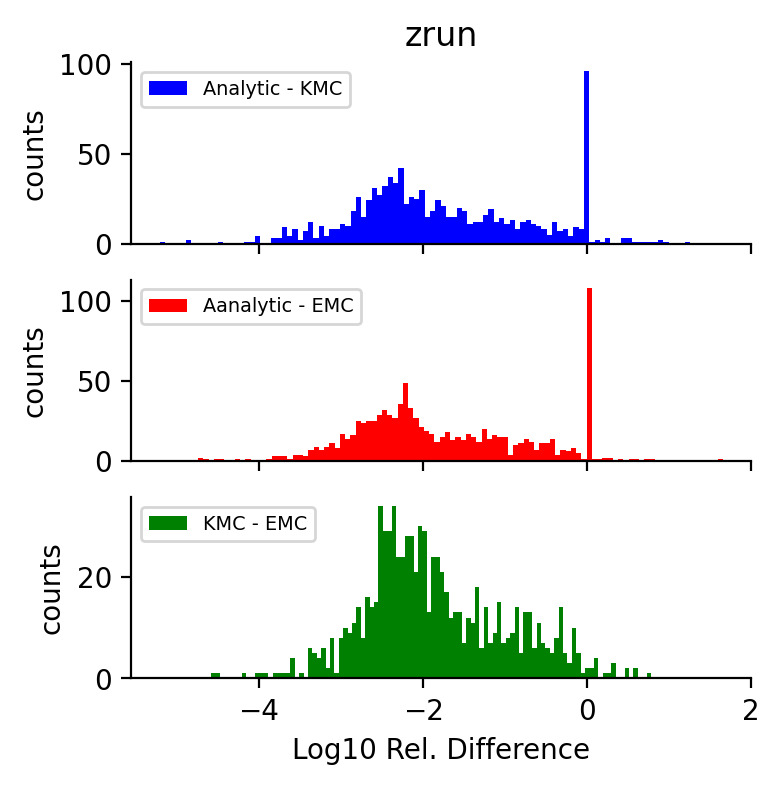

In [6]:
residuals(simres.zrunavg_ana, simres.zrunavg_kmc, simres.zrunavg_emc, 'zrun')
pass

In [8]:
print(
    simtesting.check_maxresiduals(
        "zrun",
        1000000,
        simres.motors,
        simres.kfpps,
        simres.kfpms,
        simres.zrunavg_ana,
        simres.zrunavg_kmc,
        simres.zrunavg_emc,
    )
)

Check ana - kmc with 1000000 trials:
     Max Log10 residual: 1.2537547691505235
     New Log10 resdiual -0.13314019333086136
Motor with the worst relative residual:
     kd1: 759399.1868234171 1/s
     kd2: 168817.22361464202 1/s
     kh: 207.11325399904828 1/s
     kfpp: 6.761651346818946 1/s
     kfpm: 2.2131885520553722 1/s
     zrun: 17.93720489819945


Check ana - emc with 1000000 trials:
     Max Log10 residual: 1.6591418845063521
     New Log10 resdiual -0.0337208508316716
Motor with the worst relative residual:
     kd1: 462822.7086252817 1/s
     kd2: 182.16864138214265 1/s
     kh: 3.4619937327516226 1/s
     kfpp: 434602.83134470787 1/s
     kfpm: 5130.291309922876 1/s
     zrun: 45.61859280757302


Check kmc - emc with 1000000 trials:
     Max Log10 residual: 0.7781512503836435
     New Log10 resdiual -2.555133664008391
Motor with the worst relative residual:
     kd1: 1.8593614816848352 1/s
     kd2: 2.885283410419727 1/s
     kh: 42.2761070281174 1/s
     kfpp: 753640.86

## Run Times

The relative error between run times predicted by the different methods show good agreement with most relative differences less than $10^{-2}$. However, some of the comparisons between the analytic and simulation methods have relative errors up to 1. These particular motors have very long expected average run times (greater than 1000 s in some cases) by consequence of having very long runs and very low termination probabilities (< $10^5$). As a result, the simulations pass the per-run time limit imposed to prevent sudo-infinite loops. Since the code is set up to record the time limit (100 s in this case) as the run time, the error between the analytic and simulation result is large. Notably, the comparison between simulation methods lacks similar instances, indicating that the two simulation methods behave the same. 

Increasing the time limit improves the overall agreement even with fewer trials.

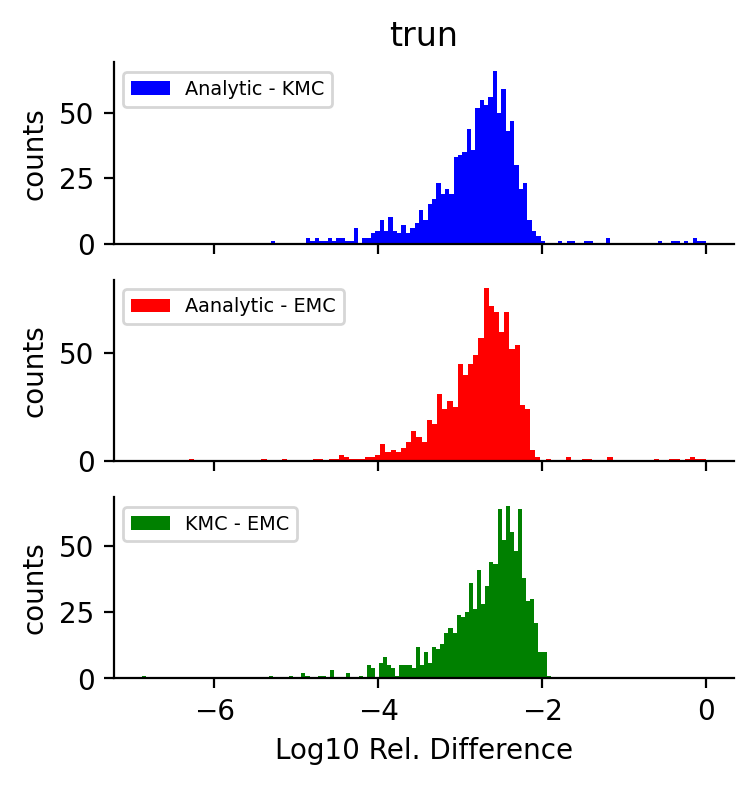

In [9]:
residuals(simres.trunavg_ana, simres.trunavg_kmc, simres.trunavg_emc, 'trun')
pass

In [11]:
print(
    simtesting.check_maxresiduals(
        "trun",
        5000,
        simres.motors,
        simres.kfpps,
        simres.kfpms,
        simres.trunavg_ana,
        simres.trunavg_kmc,
        simres.trunavg_emc,
    )
)

Check ana - kmc with 5000 trials:
     Max Log10 residual: -0.0038328656232453576
     New Log10 resdiual -1.758733047881878
Motor with the worst relative residual:
     kd1: 2.860848142274154 1/s
     kd2: 1.8530810358077696 1/s
     kh: 128364.62610014081 1/s
     kfpp: 753338.2524392536 1/s
     kfpm: 336204.4395215025 1/s
     trun: 0.9912133311544251


Check ana - emc with 5000 trials:
     Max Log10 residual: -0.003832383222245588
     New Log10 resdiual -2.2651090373726612
Motor with the worst relative residual:
     kd1: 2.860848142274154 1/s
     kd2: 1.8530810358077696 1/s
     kh: 128364.62610014081 1/s
     kfpp: 753338.2524392536 1/s
     kfpm: 336204.4395215025 1/s
     trun: 0.9912144321644251


Check kmc - emc with 5000 trials:
     Max Log10 residual: -1.895646837874184
     New Log10 resdiual -2.036299349770679
Motor with the worst relative residual:
     kd1: 117.34865245580394 1/s
     kd2: 15537.003876138984 1/s
     kh: 4.578877642846531 1/s
     kfpp: 68438.66038

## Run Velocities

The relative residuals for average run velocities determined by the different methods share many similarities to the run distance relative differences. As before, the large number of comparisons between the analytical and simulation methods with relative differences equal to 1 are due to the simulations not registering any non-zero-distance runs. Thus, only all runs have zero velocity. The comparisons with relative differences > 1 are also generally caused by motors with small average run distances, but where the simulations managed to register a non-zero-distance/velocity run. Increasing the number of trials to 1,000,000 did improve the relative error, but not much below 1.

The simulations methods agree well with each other and improve with increased trials.

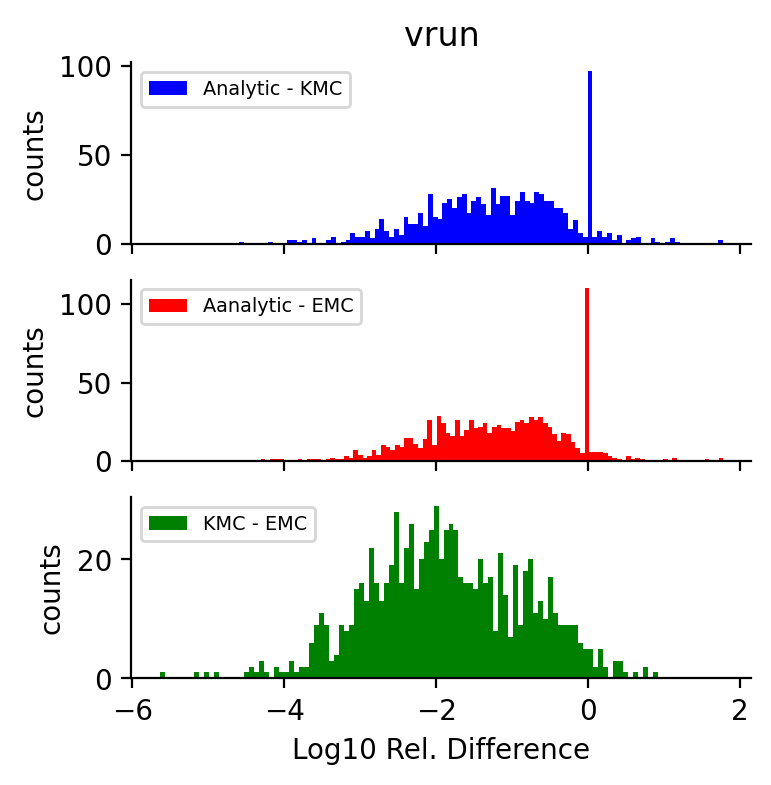

In [19]:
residuals(simres.vrunavg_ana, simres.vrunavg_kmc, simres.vrunavg_emc, 'vrun')
pass

In [18]:
print(
    simtesting.check_maxresiduals(
        "vrun",
        1000000,
        simres.motors,
        simres.kfpps,
        simres.kfpms,
        simres.vrunavg_ana,
        simres.vrunavg_kmc,
        simres.vrunavg_emc,
    )
)

Check ana - kmc with 1000000 trials:
     Max Log10 residual: 1.780283774640469
     New Log10 resdiual -0.007145159394022886
Motor with the worst relative residual:
     kd1: 2.860848142274154 1/s
     kd2: 1.8530810358077696 1/s
     kh: 128364.62610014081 1/s
     kfpp: 753338.2524392536 1/s
     kfpm: 336204.4395215025 1/s
     vrun: 60.29534363609785


Check ana - emc with 1000000 trials:
     Max Log10 residual: 1.780792672163534
     New Log10 resdiual -0.007143463332374949
Motor with the worst relative residual:
     kd1: 2.860848142274154 1/s
     kd2: 1.8530810358077696 1/s
     kh: 128364.62610014081 1/s
     kfpp: 753338.2524392536 1/s
     kfpm: 336204.4395215025 1/s
     vrun: 60.36603791582514


Check kmc - emc with 1000000 trials:
     Max Log10 residual: 0.9178318500917074
     New Log10 resdiual -1.3866032989604393
Motor with the worst relative residual:
     kd1: 4872.495187767212 1/s
     kd2: 382.4813958687228 1/s
     kh: 11.516521382336002 1/s
     kfpp: 1377.432

## Dwell Times

The relative error in the dwell times was less than ~0.01 with no apparent indications of numerical challenges. Just to confirm, additional trials did improve the relative error by an additional order of magnitude.

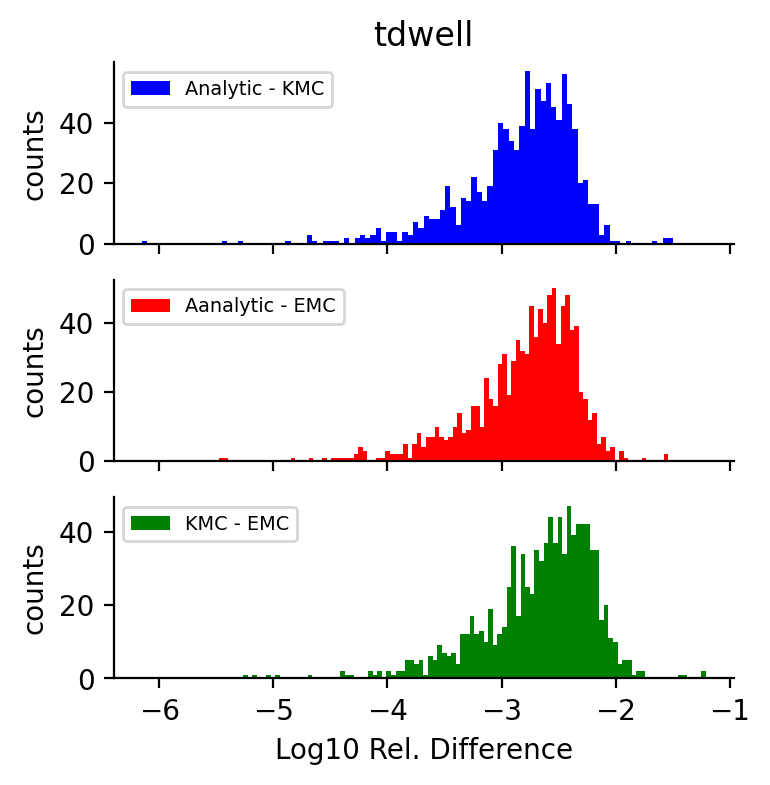

In [20]:
residuals(simres.tdwellavg_ana, simres.tdwellavg_kmc, simres.tdwellavg_emc, 'tdwell')
pass

In [19]:
print(
    simtesting.check_maxresiduals(
        "tdwell",
        1000000,
        simres.motors,
        simres.kfpps,
        simres.kfpms,
        simres.tdwellavg_ana,
        simres.tdwellavg_kmc,
        simres.tdwellavg_emc,
    )
)

Check ana - kmc with 1000000 trials:
     Max Log10 residual: -1.4944493638139091
     New Log10 resdiual -1.8837950216798427
Motor with the worst relative residual:
     kd1: 17.89095910135817 1/s
     kd2: 17670.39429290027 1/s
     kh: 9.9868711497951 1/s
     kfpp: 866030.7070058291 1/s
     kfpm: 26663.59640024061 1/s
     tdwell: 0.03202953518429227


Check ana - emc with 1000000 trials:
     Max Log10 residual: -1.5373729096602398
     New Log10 resdiual -2.945978330802628
Motor with the worst relative residual:
     kd1: 31.994768329166764 1/s
     kd2: 2489.430379715097 1/s
     kh: 4.066198041718903 1/s
     kfpp: 31389.09923551611 1/s
     kfpm: 29552.17560687283 1/s
     tdwell: 0.02901530167583348


Check kmc - emc with 1000000 trials:
     Max Log10 residual: -1.2118633828642855
     New Log10 resdiual -2.3221238963362443
Motor with the worst relative residual:
     kd1: 31.994768329166764 1/s
     kd2: 2489.430379715097 1/s
     kh: 4.066198041718903 1/s
     kfpp: 31389